# Predição de AVC — APS1: Análise Exploratória de Dados

**Dataset:** [Stroke Prediction Dataset](https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset) (Kaggle, fedesoriano)

Tarefas 1 a 3 da APS1. O pré-processamento (tarefa 4) está no notebook 02.

## Setup

Nos gráficos, azul é paciente sem AVC, laranja é paciente com AVC e violeta é o treino inteiro.

In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", rc={"axes.spines.top": False, "axes.spines.right": False,
                                     "axes.titleweight": "bold", "legend.frameon": False, "figure.dpi": 110})

AZUL, LARANJA, VIOLETA, CINZA = "#2a78d6", "#eb6834", "#4a3aa7", "#898781"
PALETA_AVC = {"Sem AVC": AZUL, "Com AVC": LARANJA}
NOMES = {"age": "Idade (anos)", "avg_glucose_level": "Glicose média (mg/dL)", "bmi": "IMC (kg/m²)"}

# Tarefa 1 — Carregamento e inspeção inicial dos dados

### 1.1 Carregamento

O CSV é baixado do Kaggle na primeira execução e reaproveitado nas seguintes.

In [2]:
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CSV_PATH = ROOT / "data" / "raw" / "healthcare-dataset-stroke-data.csv"

if not CSV_PATH.exists():
    import kagglehub
    CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(Path(kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")) / CSV_PATH.name, CSV_PATH)

df = pd.read_csv(CSV_PATH)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 1.2 Descrição das features

Cada linha é um paciente. O target é stroke, que indica se o paciente teve AVC: um problema de classificação binária. Segundo a OMS, o AVC é a segunda maior causa de morte no mundo.

| Coluna | Tipo | O que é | Valores possíveis |
|---|---|---|---|
| id | identificador | código do paciente | número inteiro, único por linha; não descreve o paciente |
| gender | categórica | gênero | Male (masculino), Female (feminino), Other (outro) |
| age | numérica | idade em anos | 0,08 a 82; bebês têm idade fracionária (0,08 = 1 mês) |
| hypertension | categórica/numérica | diagnóstico de hipertensão | 0 (não tem), 1 (tem) |
| heart_disease | categórica/numérica | diagnóstico de doença cardíaca | 0 (não tem), 1 (tem) |
| ever_married | categórica | se já foi casado(a) alguma vez | Yes (sim), No (não) |
| work_type | categórica | tipo de trabalho | Private (setor privado), Self-employed (autônomo), Govt_job (funcionário público), children (criança, não trabalha), Never_worked (nunca trabalhou) |
| Residence_type | categórica | tipo de área onde mora | Urban (urbana), Rural (rural) |
| avg_glucose_level | numérica | nível médio de glicose no sangue, em mg/dL | 55 a 272 |
| bmi | numérica | índice de massa corporal, em kg/m² | 10 a 98; tem valores ausentes |
| smoking_status | categórica | histórico de tabagismo | never smoked (nunca fumou), formerly smoked (ex-fumante), smokes (fuma), Unknown (informação indisponível) |
| stroke | categórica/numérica | **target**: se o paciente teve AVC | 0 (não teve), 1 (teve) |

Os tipos usados na tabela:

- **numérica**: quantidade contínua, livre dentro de uma faixa (idade, glicose, IMC);
- **categórica**: rótulo sem ordem natural, guardado como texto;
- **categórica/numérica**: categoria já codificada como número (0 ou 1). Parece número, mas não é uma quantidade: não faz sentido calcular média como grandeza nem padronizar. Hipertensão, doença cardíaca e o target são desse tipo.

### 1.3 Número de instâncias e features

In [3]:
df.shape

(5110, 12)

5.110 pacientes e 12 colunas: o identificador, 10 features e o target.

### 1.4 Tipos de dados

In [4]:
TARGET = "stroke"
NUM_COLS = ["age", "avg_glucose_level", "bmi"]
BIN_COLS = ["hypertension", "heart_disease"]
CAT_COLS = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

tipo = {"id": "identificador", TARGET: "categórica/numérica (target)", **dict.fromkeys(NUM_COLS, "numérica"),
        **dict.fromkeys(BIN_COLS, "categórica/numérica"), **dict.fromkeys(CAT_COLS, "categórica")}
pd.DataFrame({"tipo": pd.Series(tipo), "dtype (pandas)": df.dtypes, "valores únicos": df.nunique()})

,tipo,dtype (pandas),valores únicos
Residence_type,categórica,str,2
age,numérica,float64,104
avg_glucose_level,numérica,float64,3979
bmi,numérica,float64,418
ever_married,categórica,str,2
gender,categórica,str,3
heart_disease,categórica/numérica,int64,2
hypertension,categórica/numérica,int64,2
id,identificador,int64,5110
smoking_status,categórica,str,4


O dtype do pandas não distingue os tipos: hipertensão, doença cardíaca e o target aparecem como inteiros, mas são categóricas codificadas como 0 e 1 (categórica/numérica). Elas ficam como estão na modelagem e não são padronizadas. As colunas de texto são categóricas nominais, sem ordem. Só idade, glicose e IMC são numéricas de verdade, com 104, 3.979 e 418 valores distintos. O id é único por linha e não entra na análise.

### 1.5 Valores ausentes e inconsistências

In [5]:
df.isna().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
print("Tabagismo desconhecido:", df["smoking_status"].eq("Unknown").sum())
print("Gênero Other:", df["gender"].eq("Other").sum())
print("Linhas duplicadas:", df.drop(columns="id").duplicated().sum())

Tabagismo desconhecido: 1544
Gênero Other: 1
Linhas duplicadas: 0


In [7]:
suspeitos = {
    "idade fracionária": df["age"] % 1 != 0,
    "fuma ou fumou com menos de 12 anos": df["smoking_status"].isin(["smokes", "formerly smoked"]) & (df["age"] < 12),
    "IMC acima de 60": df["bmi"] > 60,
    "AVC antes dos 20 anos": (df[TARGET] == 1) & (df["age"] < 20),
}
pd.Series({regra: mascara.sum() for regra, mascara in suspeitos.items()}, name="pacientes")

idade fracionária                     115
fuma ou fumou com menos de 12 anos      6
IMC acima de 60                        13
AVC antes dos 20 anos                   2
Name: pacientes, dtype: int64

In [8]:
df.groupby(df["bmi"].isna().rename("IMC ausente"))[TARGET].agg(pacientes="size", casos_avc="sum", taxa_avc=lambda s: round(s.mean() * 100, 1))

,pacientes,casos_avc,taxa_avc
IMC ausente,,,
False,4909,209,4.3
True,201,40,19.9


Só o IMC tem nulos: 201 pacientes (3,9%). A ausência não é aleatória: 19,9% de AVC entre quem não tem IMC, contra 4,3% dos demais, e 40 dos 249 casos estão nesse grupo. Por isso o IMC será imputado, e não removido, guardando a informação de que estava ausente.

O tabagismo desconhecido (30%) é uma ausência disfarçada de categoria. O gênero tem um único paciente na categoria Other. Não há duplicatas.

As idades fracionárias são bebês registrados em meses, não erros. Restam poucos casos suspeitos: 6 crianças marcadas como fumantes, 13 IMCs acima de 60 (implausíveis, serão limitados) e 2 AVCs antes dos 20 anos, que ficam como estão.

### 1.6 Desbalanceamento de classes

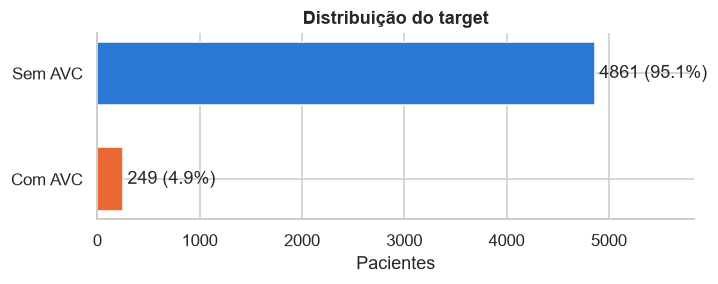

Acurácia de prever sempre 'Sem AVC': 95.1%


In [9]:
contagem = df[TARGET].value_counts().rename({0: "Sem AVC", 1: "Com AVC"})

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.barh(contagem.index, contagem.values, color=[AZUL, LARANJA], height=0.6)
ax.bar_label(ax.containers[0], labels=[f"{n} ({n / len(df):.1%})" for n in contagem], padding=3)
ax.invert_yaxis()
ax.set(title="Distribuição do target", xlabel="Pacientes", xlim=(0, contagem.max() * 1.2))
plt.show()

print(f"Acurácia de prever sempre 'Sem AVC': {contagem['Sem AVC'] / len(df):.1%}")

Só 4,9% dos pacientes tiveram AVC. Prever sempre a classe majoritária acerta 95,1%, então a acurácia não serve; a avaliação deve usar recall, precisão e F1 da classe positiva.

### 1.7 Separação em treino e teste

O id é removido, e também o único paciente com gênero Other, que não pode ser aprendido nem avaliado. Divisão 80/20 estratificada pelo target, com semente fixa. Daqui em diante só o treino é usado; o teste fica reservado para a avaliação final.

In [10]:
df = df.drop(columns="id").query("gender != 'Other'")
X_train, X_test, y_train, y_test = train_test_split(
    df.drop(columns=TARGET), df[TARGET], test_size=0.2, stratify=df[TARGET], random_state=RANDOM_STATE
)

PROCESSED = ROOT / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)
X_train.assign(stroke=y_train).to_csv(PROCESSED / "train.csv", index=False)
X_test.assign(stroke=y_test).to_csv(PROCESSED / "test.csv", index=False)

train = X_train.assign(stroke=y_train, AVC=y_train.map({0: "Sem AVC", 1: "Com AVC"}))
pd.DataFrame({"pacientes": [len(y_train), len(y_test)], "casos de AVC": [y_train.sum(), y_test.sum()],
              "% AVC": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)]}, index=["treino", "teste"])

,pacientes,casos de AVC,% AVC
treino,4087,199,4.87
teste,1022,50,4.89


# Tarefa 2 — Análise univariada

### 2.1 Estatísticas descritivas

In [11]:
train[NUM_COLS].describe().T.join(train[NUM_COLS].skew().rename("assimetria")).round(2)

,count,mean,std,min,25%,50%,75%,max,assimetria
age,4087.0,43.26,22.64,0.08,25.00,45.00,61.00,82.00,-0.14
avg_glucose_level,4087.0,105.90,44.68,55.22,77.46,91.89,114.04,271.74,1.58
bmi,3924.0,28.88,7.90,10.30,23.50,28.10,33.10,97.60,1.12


A idade é simétrica. Glicose e IMC têm cauda à direita: a média fica acima da mediana e a assimetria é positiva, mais forte na glicose (1,58). As escalas são diferentes e vão exigir padronização.

### 2.2 Distribuições das variáveis numéricas

In [12]:
q1, q3 = train[NUM_COLS].quantile(0.25), train[NUM_COLS].quantile(0.75)
fora = (train[NUM_COLS] < q1 - 1.5 * (q3 - q1)) | (train[NUM_COLS] > q3 + 1.5 * (q3 - q1))
fora.sum().rename("outliers pelo critério IQR")

age                    0
avg_glucose_level    489
bmi                   86
Name: outliers pelo critério IQR, dtype: int64

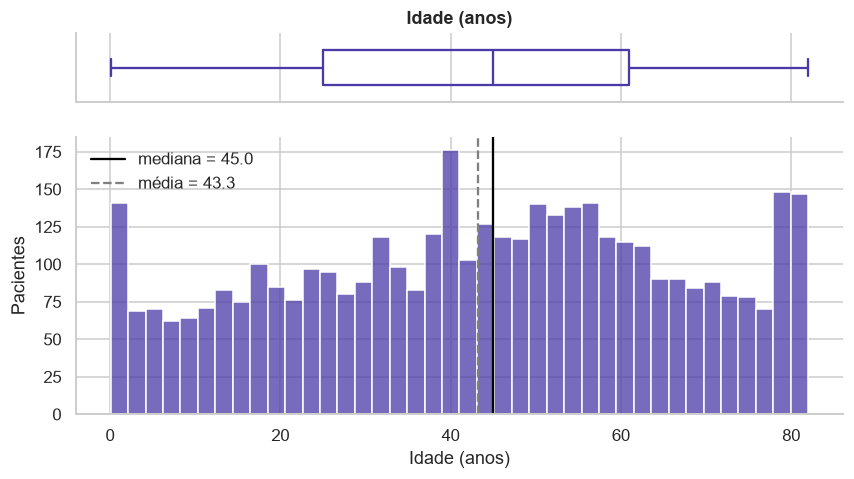

In [13]:
def hist_box(col):
    dados = train[col].dropna()
    fig, (ax_box, ax_hist) = plt.subplots(2, 1, figsize=(9, 4.5), sharex=True, gridspec_kw={"height_ratios": [1, 4]})
    sns.boxplot(x=dados, ax=ax_box, color=VIOLETA, fill=False, width=0.5)
    sns.histplot(dados, bins=40, ax=ax_hist, color=VIOLETA)
    ax_hist.axvline(dados.median(), color="black", label=f"mediana = {dados.median():.1f}")
    ax_hist.axvline(dados.mean(), color="gray", ls="--", label=f"média = {dados.mean():.1f}")
    ax_box.set(title=NOMES[col], xlabel="", yticks=[])
    ax_hist.set(xlabel=NOMES[col], ylabel="Pacientes")
    ax_hist.legend()
    plt.show()


hist_box("age")

Sem outliers. Há um acúmulo de bebês com menos de 2 anos e um pico em 80–82 anos, que sugere idades maiores registradas como 82.

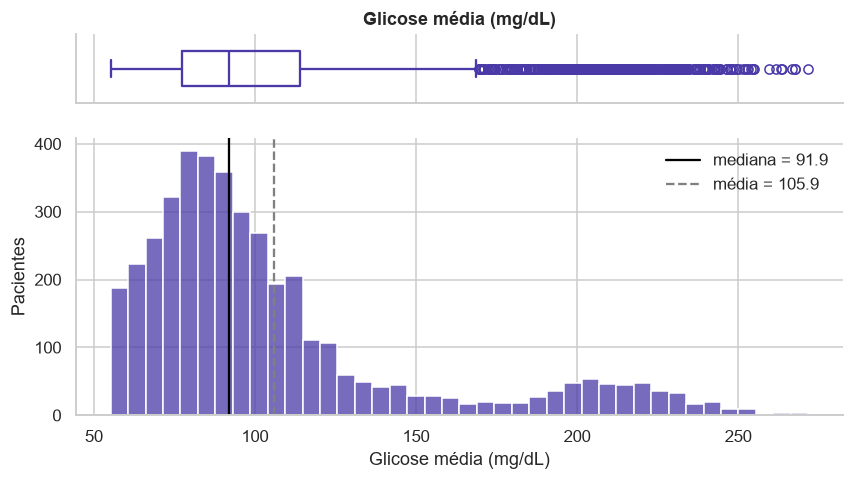

In [14]:
hist_box("avg_glucose_level")

Distribuição bimodal: a maioria entre 60 e 130 e um segundo grupo em torno de 200, compatível com diabetes. Os 489 outliers (12%) são esse grupo, com 13,5% de AVC, o triplo da taxa geral. Serão mantidos, com transformação logarítmica.

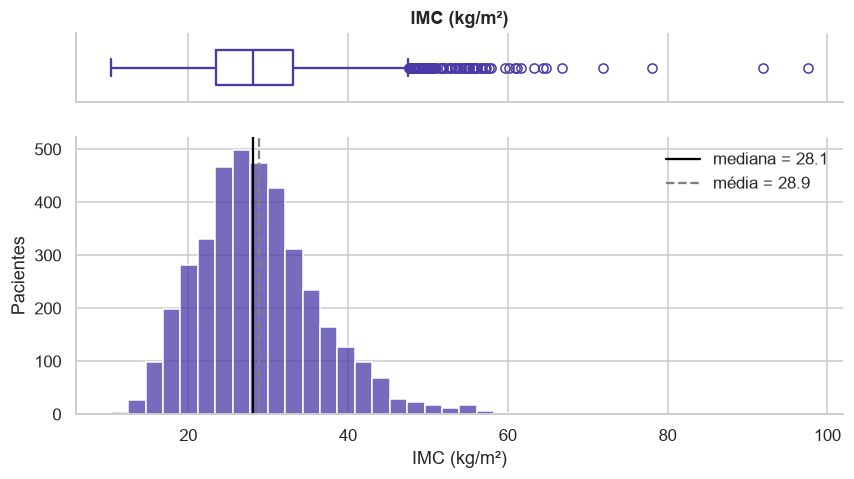

In [15]:
hist_box("bmi")

Quase simétrico em torno de 28, com cauda à direita. Dos 86 outliers, 12 passam de 60 e são provavelmente erros de registro; serão limitados, sem remover pacientes.

### 2.3 Frequências das variáveis categóricas

In [16]:
frequencias = pd.concat({col: train[col].value_counts() for col in BIN_COLS + CAT_COLS}, names=["variável", "categoria"])
frequencias.to_frame("pacientes").assign(**{"%": (frequencias / len(train) * 100).round(1)})

pacientes     %
variável       categoria                       
hypertension   0                     3700  90.5
               1                      387   9.5
heart_disease  0                     3855  94.3
               1                      232   5.7
gender         Female                2397  58.6
               Male                  1690  41.4
ever_married   Yes                   2697  66.0
               No                    1390  34.0
work_type      Private               2324  56.9
               Self-employed          664  16.2
               children               555  13.6
               Govt_job               528  12.9
               Never_worked            16   0.4
Residence_type Urban                 2054  50.3
               Rural                 2033  49.7
smoking_status never smoked          1520  37.2
               Unknown               1236  30.2
               formerly smoked        715  17.5
               smokes                 616  15.1

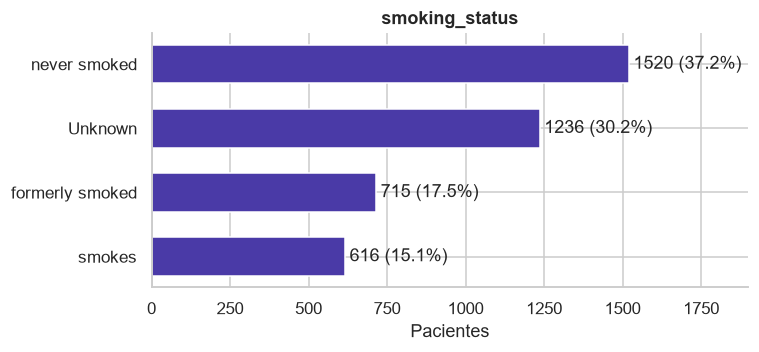

In [17]:
def frequencia(col):
    contagem = train[col].value_counts()
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(contagem) + 1))
    ax.barh(contagem.index, contagem.values, color=VIOLETA, height=0.6)
    ax.bar_label(ax.containers[0], labels=[f"{n} ({n / len(train):.1%})" for n in contagem], padding=3)
    ax.invert_yaxis()
    ax.set(title=col, xlabel="Pacientes", xlim=(0, contagem.max() * 1.25))
    plt.show()


frequencia("smoking_status")

O status desconhecido é a segunda categoria mais frequente (30%). Imputar pela moda transformaria um terço dos pacientes em não fumantes, então a categoria será mantida.

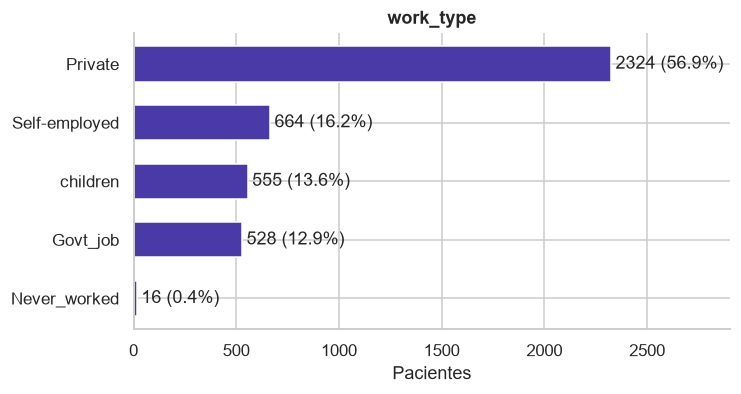

In [18]:
frequencia("work_type")

Mais da metade dos pacientes trabalha no setor privado. A categoria de crianças descreve idade, não profissão; quem nunca trabalhou são só 16 pacientes.

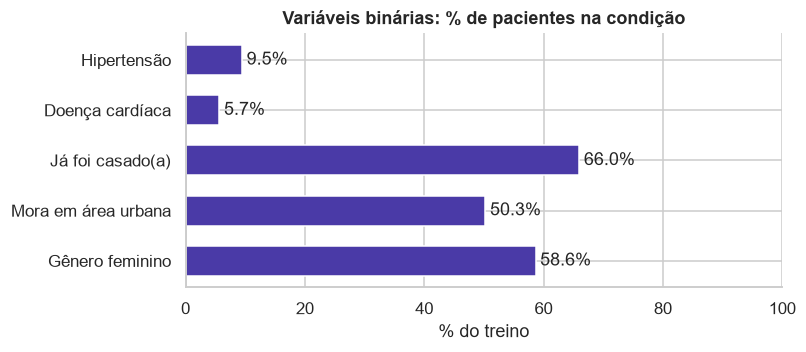

In [19]:
binarias = pd.Series({
    "Hipertensão": train["hypertension"].mean(),
    "Doença cardíaca": train["heart_disease"].mean(),
    "Já foi casado(a)": train["ever_married"].eq("Yes").mean(),
    "Mora em área urbana": train["Residence_type"].eq("Urban").mean(),
    "Gênero feminino": train["gender"].eq("Female").mean(),
}) * 100

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(binarias.index, binarias.values, color=VIOLETA, height=0.6)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.invert_yaxis()
ax.set(title="Variáveis binárias: % de pacientes na condição", xlabel="% do treino", xlim=(0, 100))
plt.show()

Hipertensão (9,5%) e doença cardíaca (5,7%) são minoritárias. Residência é meio a meio, há leve maioria feminina e dois terços já foram casados. Nenhuma categoria é rara demais para virar 0/1.

# Tarefa 3 — Análise bivariada e multivariada

Como o target é desbalanceado, as comparações entre grupos usam a taxa de AVC (% do grupo que teve AVC), e não a contagem de casos.

### 3.1 Correlações entre variáveis numéricas

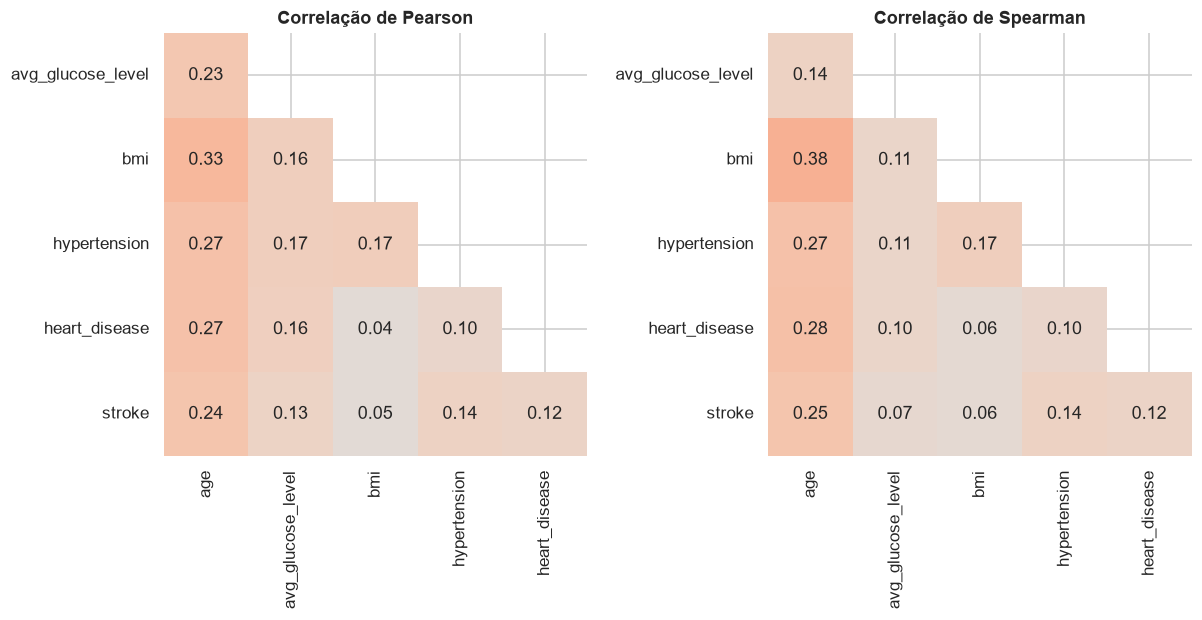

In [20]:
cols = NUM_COLS + BIN_COLS + [TARGET]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metodo in zip(axes, ["pearson", "spearman"]):
    corr = train[cols].corr(method=metodo).iloc[1:, :-1]
    sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), ax=ax, cmap="coolwarm", vmin=-1, vmax=1,
                annot=True, fmt=".2f", square=True, cbar=False)
    ax.set_title(f"Correlação de {metodo.capitalize()}")
plt.show()

Pearson mede relação linear; Spearman usa a ordem dos valores e é robusta a outliers. Não há correlação forte entre features (máximo 0,33, entre idade e IMC), então não há multicolinearidade. A idade é a mais associada ao AVC (0,24), seguida de hipertensão, glicose e doença cardíaca; o IMC quase não se relaciona. A idade se correlaciona com quase todas as outras variáveis, o que a torna uma provável confundidora. Em Spearman, a correlação de glicose com AVC cai de 0,13 para 0,07: a associação vem do grupo com glicose muito alta, não de um aumento gradual.

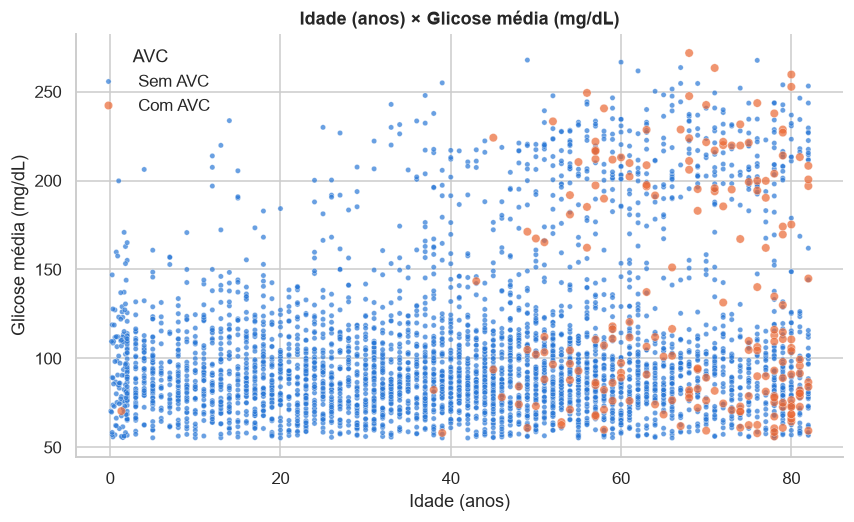

In [21]:
def dispersao(x, y):
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.scatterplot(data=train.sort_values(TARGET), x=x, y=y, hue="AVC", palette=PALETA_AVC,
                    size="AVC", sizes={"Sem AVC": 12, "Com AVC": 30}, alpha=0.7, ax=ax)
    ax.set(title=f"{NOMES[x]} × {NOMES[y]}", xlabel=NOMES[x], ylabel=NOMES[y])
    plt.show()


dispersao("age", "avg_glucose_level")

Os casos de AVC quase não aparecem antes dos 40 anos (3 dos 199) e se concentram a partir dos 60. A faixa de glicose acima de 170 tem mais AVC mesmo entre idosos. As classes se sobrepõem muito; nenhuma fronteira simples as separa.

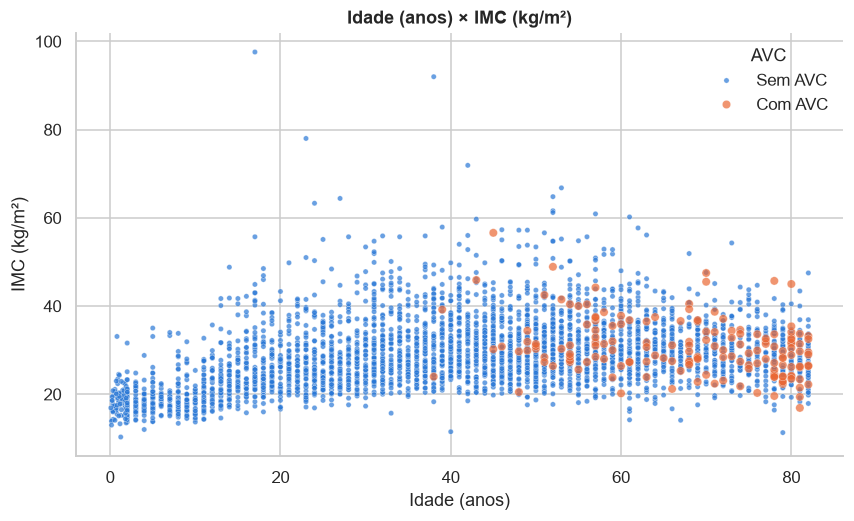

In [22]:
dispersao("age", "bmi")

O IMC cresce com a idade só até a adolescência; entre adultos a correlação é praticamente zero. Os casos de AVC se espalham por toda a faixa usual de IMC.

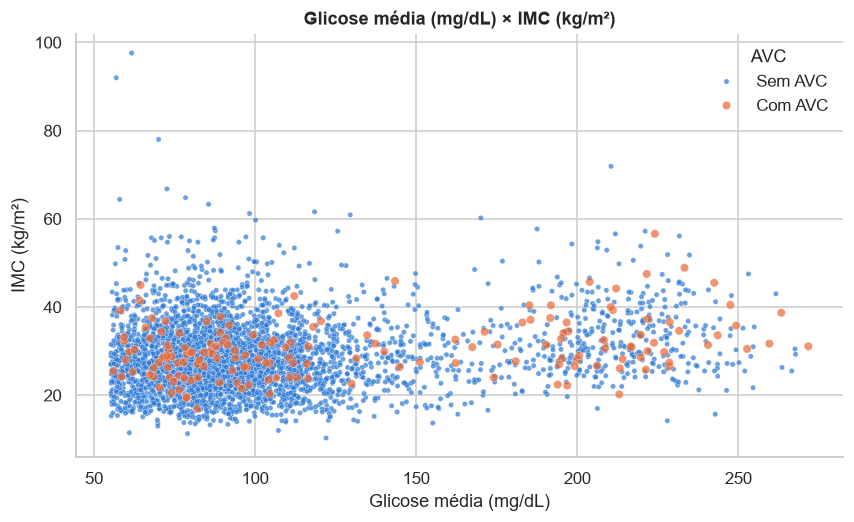

In [23]:
dispersao("avg_glucose_level", "bmi")

Glicose e IMC quase não se relacionam (correlação de 0,16): o grupo de glicose alta tem IMC espalhado por toda a faixa. Os casos de AVC aparecem nos dois grupos de glicose e em qualquer IMC, então as duas variáveis juntas não formam uma fronteira clara.

### 3.2 Variáveis categóricas × target

In [24]:
def contingencia(col):
    tabela = pd.crosstab(train[col], train["AVC"])[["Sem AVC", "Com AVC"]]
    tabela["taxa de AVC (%)"] = (tabela["Com AVC"] / tabela.sum(axis=1) * 100).round(1)
    return tabela


pd.concat({col: contingencia(col) for col in BIN_COLS + CAT_COLS}, names=["variável", "categoria"])

AVC                             Sem AVC  Com AVC  taxa de AVC (%)
variável       categoria                                         
hypertension   0                   3555      145              3.9
               1                    333       54             14.0
heart_disease  0                   3692      163              4.2
               1                    196       36             15.5
gender         Female              2285      112              4.7
               Male                1603       87              5.1
ever_married   No                  1367       23              1.7
               Yes                 2521      176              6.5
work_type      Govt_job             500       28              5.3
               Never_worked          16        0              0.0
               Private             2209      115              4.9
               Self-employed        609       55              8.3
               children             554        1              0.2
Residence_type Rural               1942       91              4.5
               Urban               1946      108              5.3
smoking_status Unknown             1198       38              3.1
               formerly smoked      659       56              7.8
               never smoked        1449       71              4.7
               smokes               582       34              5.5

In [25]:
def associacao(col):
    chi2, p, *_ = stats.chi2_contingency(pd.crosstab(train[col], train[TARGET]))
    return pd.Series({"V de Cramér": np.sqrt(chi2 / len(train)), "p-valor (qui-quadrado)": p})


pd.DataFrame({col: associacao(col) for col in BIN_COLS + CAT_COLS}).T.sort_values("V de Cramér", ascending=False).round(3)

,V de Cramér,p-valor (qui-quadrado)
hypertension,0.135,0.000
heart_disease,0.119,0.000
ever_married,0.106,0.000
work_type,0.104,0.000
smoking_status,0.075,0.000
Residence_type,0.017,0.276
gender,0.010,0.534


Todas as associações com o target são significativas (p < 0,001), exceto gênero e tipo de residência. As mais fortes são hipertensão e doença cardíaca, com V de Cramér de 0,13 e 0,12. Mesmo essas são fracas, o que antecipa a dificuldade da classificação.

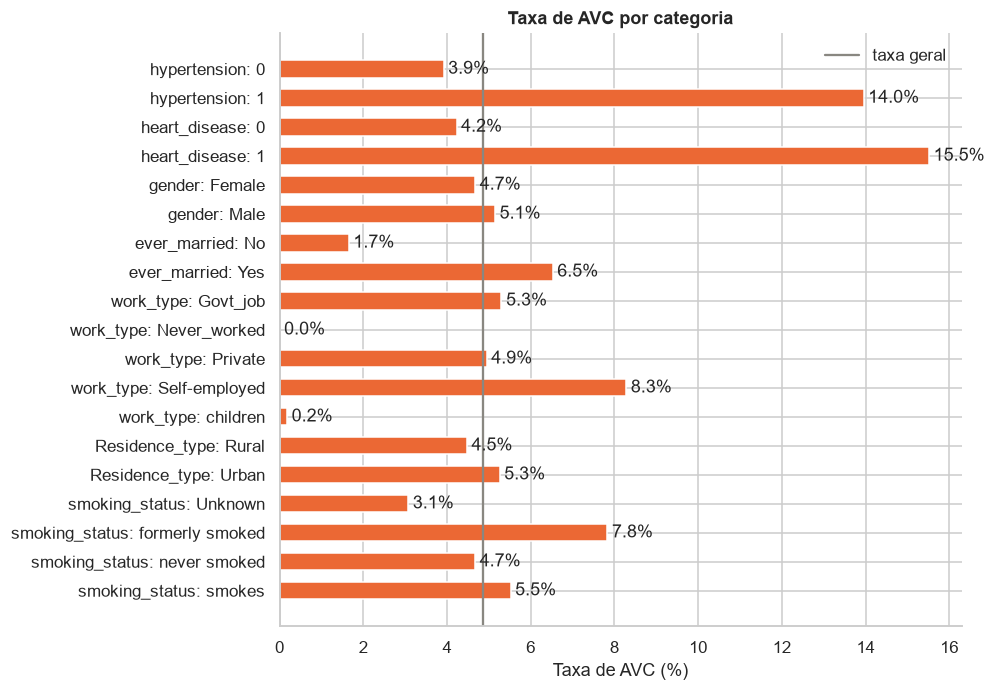

In [26]:
taxas = pd.concat({col: train.groupby(col)[TARGET].mean() * 100 for col in BIN_COLS + CAT_COLS})
taxas.index = [f"{var}: {cat}" for var, cat in taxas.index]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(taxas.index, taxas.values, color=LARANJA, height=0.6)
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
ax.axvline(train[TARGET].mean() * 100, color=CINZA, label="taxa geral")
ax.invert_yaxis()
ax.set(title="Taxa de AVC por categoria", xlabel="Taxa de AVC (%)")
ax.legend()
plt.show()

Hipertensão e doença cardíaca têm as maiores diferenças: 14% a 15% de AVC com a condição, contra 4% sem. Estado civil, tipo de trabalho e tabagismo também variam; gênero e residência quase nada. Como a idade é o fator mais ligado ao AVC e varia muito entre as categorias, a tabela seguinte compara as taxas dentro de cada faixa etária.

In [27]:
train["faixa etária"] = pd.cut(train["age"], [0, 40, 60, 82], labels=["até 40", "41 a 60", "mais de 60"])

pd.concat({col: pd.crosstab(train[col], train["faixa etária"], values=train[TARGET], aggfunc="mean") for col in BIN_COLS + CAT_COLS},
          names=["variável", "categoria"]).mul(100).round(1)

faixa etária                    até 40  41 a 60  mais de 60
variável       categoria                                   
hypertension   0                   0.1      4.0        11.8
               1                   2.9      9.0        18.8
heart_disease  0                   0.2      4.4        12.5
               1                   0.0      9.8        17.3
gender         Female              0.3      4.7        12.3
               Male                0.0      4.5        14.7
ever_married   No                  0.2      4.8        20.0
               Yes                 0.2      4.6        12.7
work_type      Govt_job            0.0      4.1        12.1
               Never_worked        0.0      NaN         NaN
               Private             0.1      5.0        14.0
               Self-employed       1.1      3.4        12.7
               children            0.2      NaN         NaN
Residence_type Rural               0.1      3.9        12.9
               Urban               0.2      5.2        13.6
smoking_status Unknown             0.1      4.8        12.7
               formerly smoked     0.6      4.2        14.7
               never smoked        0.0      3.6        13.2
               smokes              0.5      6.6        11.6

Dentro de cada faixa etária, as diferenças de estado civil, tipo de trabalho e tabagismo praticamente desaparecem; as de hipertensão e doença cardíaca permanecem. Os dois gráficos seguintes mostram um caso de cada.

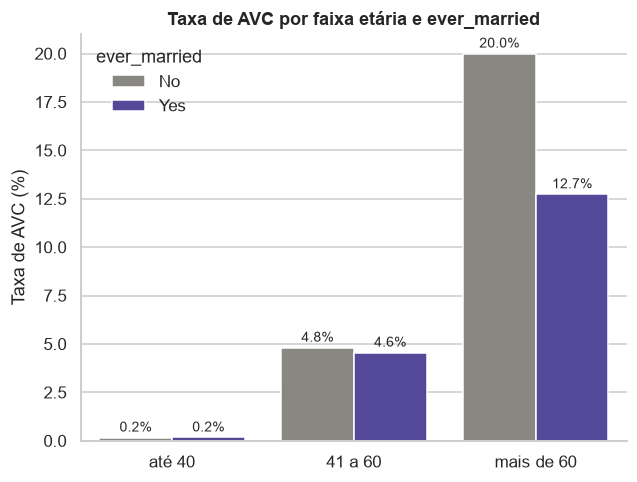

In [28]:
def taxa_por_faixa(col, ax=None):
    ax = sns.barplot(data=train, x="faixa etária", y=train[TARGET] * 100, hue=col, hue_order=sorted(train[col].unique()),
                     palette=[CINZA, VIOLETA], errorbar=None, ax=ax)
    for barras in ax.containers:
        ax.bar_label(barras, fmt="%.1f%%", padding=2, fontsize=9)
    ax.set(title=f"Taxa de AVC por faixa etária e {col}", xlabel="", ylabel="Taxa de AVC (%)")


taxa_por_faixa("ever_married")
plt.show()

Casados e não casados têm a mesma taxa dentro de cada faixa, e acima dos 60 anos a relação se inverte. A diferença geral (6,5% contra 1,7%) vem da idade: mediana de 54 anos entre casados e 18 entre os demais. É um exemplo do paradoxo de Simpson.

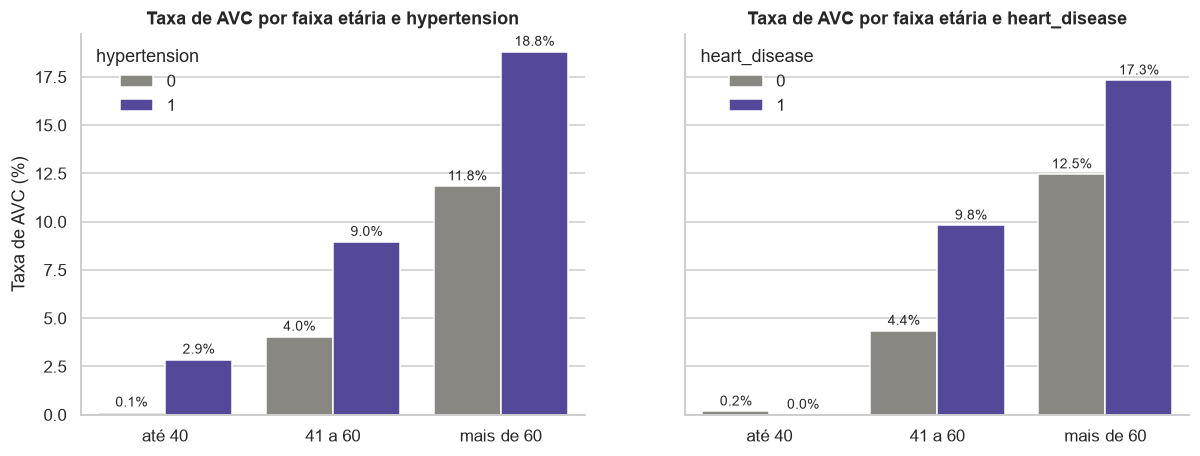

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
taxa_por_faixa("hypertension", axes[0])
taxa_por_faixa("heart_disease", axes[1])
plt.show()

Hipertensão e doença cardíaca elevam a taxa em todas as faixas: entre 41 e 60 anos ela dobra, e acima dos 60 sobe de 12% para 17% a 19%. São fatores de risco próprios, além da idade.

### 3.3 Variáveis numéricas × categóricas

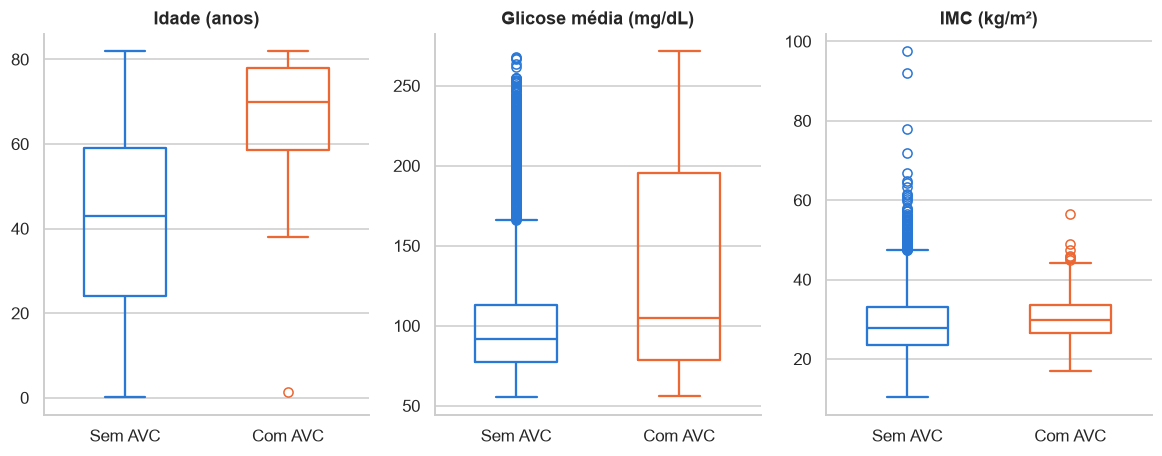

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, col in zip(axes, NUM_COLS):
    sns.boxplot(data=train, x="AVC", y=col, hue="AVC", palette=PALETA_AVC, fill=False, width=0.5, legend=False, ax=ax)
    ax.set(title=NOMES[col], xlabel="", ylabel="")
plt.show()

In [31]:
def diferenca(col):
    com, sem = train.loc[train[TARGET] == 1, col].dropna(), train.loc[train[TARGET] == 0, col].dropna()
    return pd.Series({"mediana com AVC": com.median(), "mediana sem AVC": sem.median(),
                      "p-valor (Mann-Whitney)": stats.mannwhitneyu(com, sem).pvalue})


pd.DataFrame({col: diferenca(col) for col in NUM_COLS}).T.round(4)

,mediana com AVC,mediana sem AVC,p-valor (Mann-Whitney)
age,70.00,43.00,0.0000
avg_glucose_level,104.86,91.59,0.0000
bmi,29.90,27.90,0.0002


A idade é o que mais separa as classes: mediana de 70 anos com AVC contra 43 sem. A glicose muda pouco na mediana, mas um terço dos casos de AVC está acima de 170. O IMC quase não muda. O teste de Mann-Whitney confirma diferença significativa nas três, mas com magnitudes muito diferentes.

In [32]:
faixa_glicose = pd.cut(train["avg_glucose_level"], [0, 100, 126, 170, 300], labels=["até 100", "100 a 126", "126 a 170", "acima de 170"])
pd.crosstab(faixa_glicose, train["faixa etária"], values=train[TARGET], aggfunc="mean").mul(100).round(1)

faixa etária,até 40,41 a 60,mais de 60
avg_glucose_level,,,
até 100,0.3,3.5,11.0
100 a 126,0.0,3.9,11.7
126 a 170,0.0,4.4,16.7
acima de 170,0.0,10.4,18.5


In [33]:
adultos = train[train["age"] >= 18]
faixa_imc = pd.cut(adultos["bmi"], [0, 18.5, 25, 30, 100], labels=["abaixo do peso", "normal", "sobrepeso", "obesidade"])
adultos.groupby(faixa_imc, observed=True)[TARGET].agg(pacientes="size", taxa_avc=lambda s: round(s.mean() * 100, 1))

,pacientes,taxa_avc
bmi,,
abaixo do peso,34,2.9
normal,699,4.1
sobrepeso,1050,5.1
obesidade,1473,5.3


Controlando a idade, a glicose acima de 170 ainda eleva o risco: 10,4% contra 3,5% entre 41 e 60 anos, e 18,5% contra 11,0% acima de 60. O IMC, entre adultos, mostra só um leve aumento com o peso (de 2,9% a 5,3%).

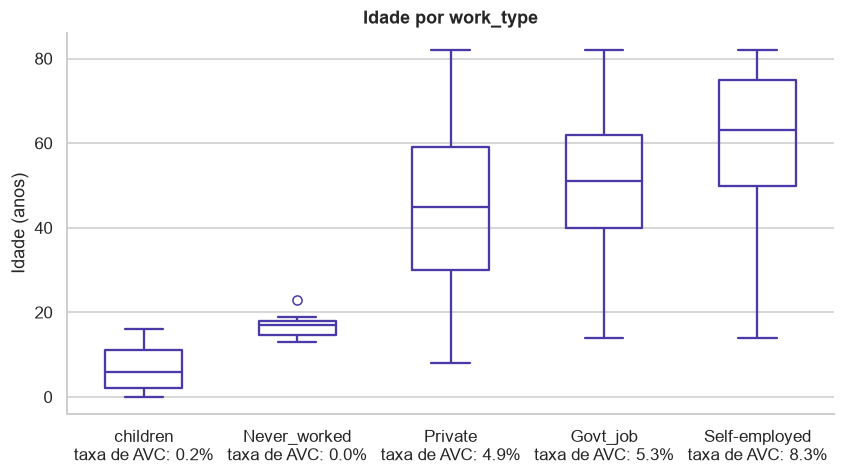

In [34]:
def idade_por(col):
    ordem = train.groupby(col)["age"].median().sort_values().index
    taxas = train.groupby(col)[TARGET].mean() * 100
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.boxplot(data=train, x=col, y="age", order=ordem, color=VIOLETA, fill=False, width=0.5, ax=ax)
    ax.set_xticks(range(len(ordem)), [f"{c}\ntaxa de AVC: {taxas[c]:.1f}%" for c in ordem])
    ax.set(title=f"Idade por {col}", xlabel="", ylabel=NOMES["age"])
    plt.show()


idade_por("work_type")

Ordenadas pela idade mediana, as categorias ficam também ordenadas pela taxa de AVC: crianças e quem nunca trabalhou são jovens e quase não têm AVC; autônomos são os mais velhos (mediana 63) e têm a maior taxa. Boa parte da variação do tipo de trabalho é idade.

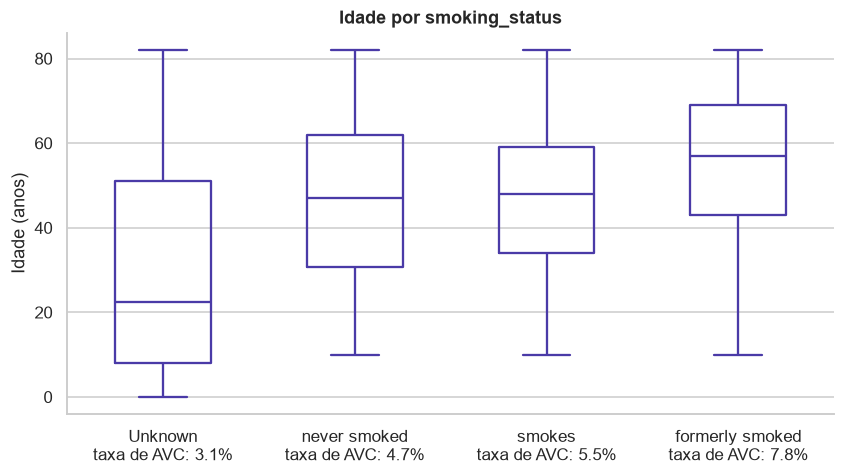

In [35]:
idade_por("smoking_status")

O grupo com status desconhecido é o mais jovem (mediana 22 anos): 90% das crianças estão nele. A maior taxa entre ex-fumantes acompanha a idade, já que é o grupo mais velho. O status desconhecido carrega informação e será mantido como categoria.

# Resumo

1. Só 4,9% dos pacientes tiveram AVC; a acurácia não serve como métrica.
2. A idade é o fator dominante: mediana de 70 anos entre os casos e só 3 casos abaixo de 40.
3. Hipertensão, doença cardíaca e glicose acima de 170 elevam o risco mesmo dentro da mesma faixa etária.
4. Os outliers de glicose são um grupo real, com o triplo da taxa de AVC: devem ser mantidos.
5. Estado civil, tipo de trabalho e parte do tabagismo só parecem ligados ao AVC por causa da idade.
6. IMC, gênero e tipo de residência trazem pouca informação.
7. O IMC ausente e o tabagismo desconhecido não são aleatórios: devem virar informação, não ser descartados.
8. Nenhuma variável separa as classes sozinha; as associações são todas fracas.

O pré-processamento que aplica essas conclusões está no notebook 02.